FRAUDDETECTPRO - FIXED DATA PREPARATION PIPELINE

📂 Step 1: Loading raw data...
   Raw shape: (284807, 31)
   Fraud cases: 492 (0.1727%)
   ✓ No missing values

📋 Sample data:


,Time,V1,V2,V3,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,149.62,0
1,0.0,1.191857,0.266151,0.166480,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,123.50,0
4,2.0,-1.158233,0.877737,1.548718,69.99,0



📊 Step 2: Separating features and target...
   Features: (284807, 30)
   Target: (284807,)
   Class distribution: Legit=284315, Fraud=492

🔀 Step 3: Train-test split (BEFORE scaling)...
   ⚠️  CRITICAL: Split BEFORE scaling to prevent data leakage!
   Train: (227845, 30)
   Test: (56962, 30)
   Train fraud: 394 (0.1729%)
   Test fraud: 98 (0.1720%)

⚙️  Step 4: Scaling features...
   ⚠️  CRITICAL: Fit scaler ONLY on training data!
   ✓ Train scaled: mean=0.000000, std=1.000000
   ✓ Test scaled: mean=-0.000127, std=1.004007
   ✓ Scaling successful (train mean ≈ 0)

🔄 Step 5: Applying SMOTE-Tomek...
   Before: Legit=227451, Fraud=394
   After: Legit=227451, Fraud=113725
   Fraud ratio: 33.33%
   ✓ Balanced to 1:3 ratio

📊 Generating visualizations...


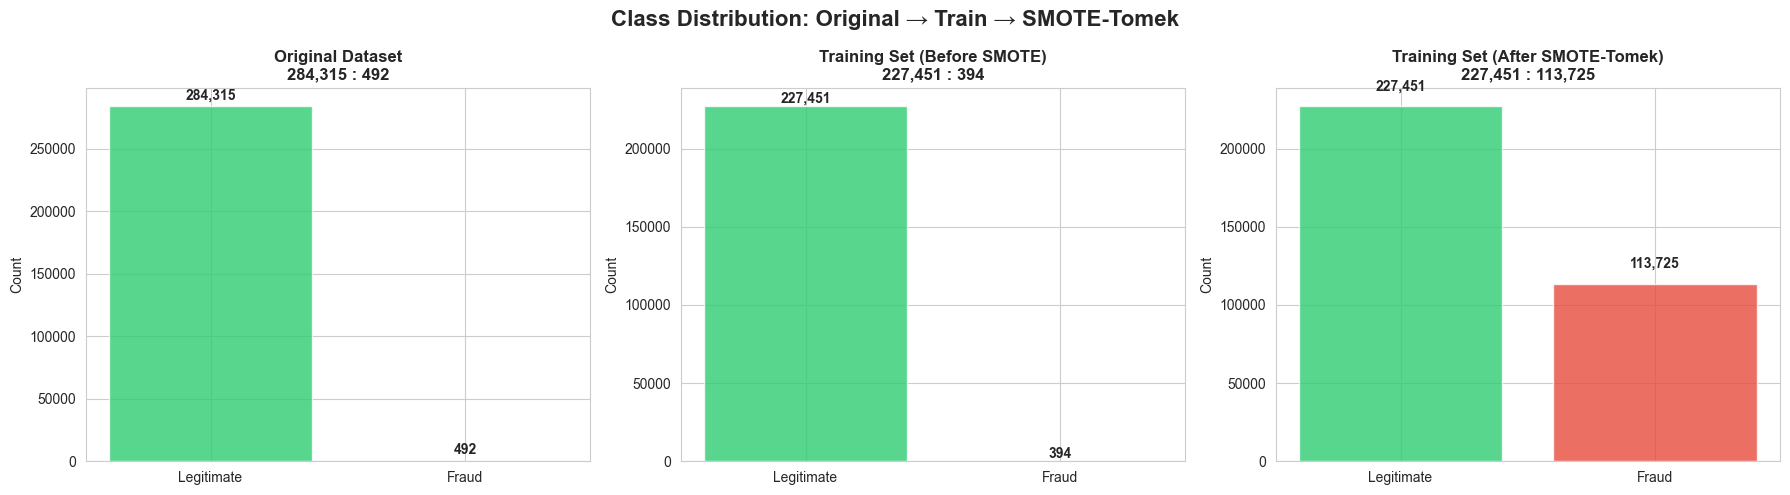


📊 Visualizing scaling effect...


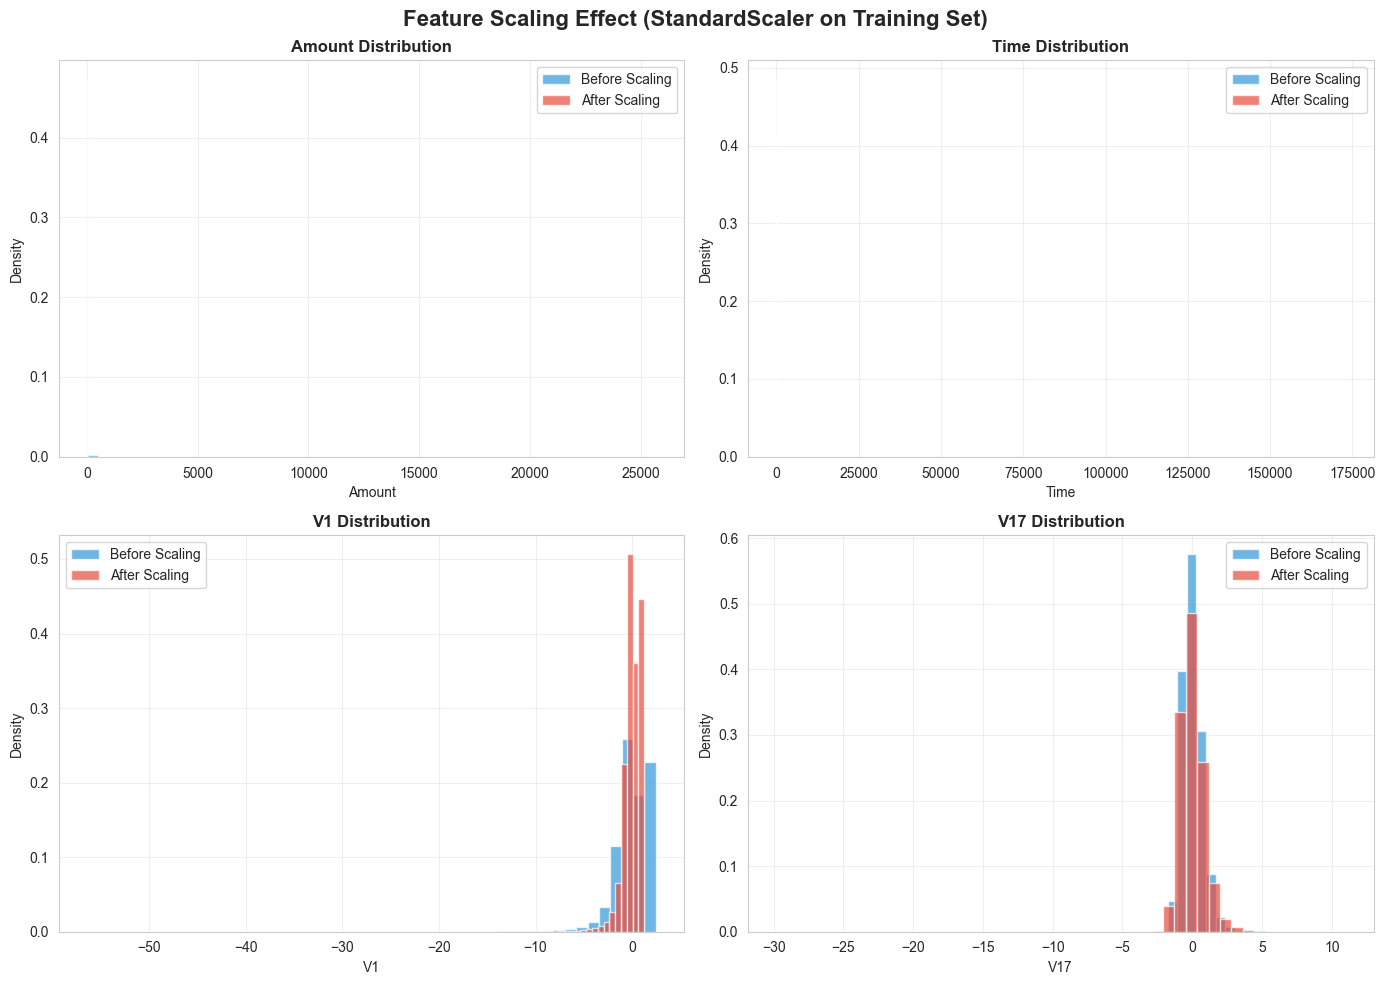


💾 Step 6: Saving processed files...
   ✓ X_train.npy (resampled)
   ✓ y_train.npy (resampled)
   ✓ X_test.npy (scaled, original distribution)
   ✓ y_test.npy (original distribution)
   ✓ feature_names.npy
   ✓ scaler.pkl

🔍 Step 7: Verification...
   ✓ Train shape: (341176, 30)
   ✓ Test shape: (56962, 30)
   ✓ Feature names: 30

   📊 Final distributions:
   Train fraud: 113,725 / 341,176 (33.33%)
   Test fraud: 98 / 56,962 (0.1720%)
   ✓ SMOTE successfully applied (train vs test distribution differs)

   📏 Scaling verification:
   Train mean: -0.430194 (should be ≈ 0)
   Train std: 2.757590 (should be ≈ 1)
   Test mean: -0.000127 (should be ≈ 0)
   Test std: 1.004007 (should be ≈ 1)

✅ DATA PREPARATION COMPLETE!

📋 Summary:
   1. ✓ Loaded 284,807 transactions
   2. ✓ Train-test split (80/20) BEFORE scaling
   3. ✓ StandardScaler fitted ONLY on training data
   4. ✓ SMOTE-Tomek applied to training data
   5. ✓ Test data preserved with original distribution

📊 Final Dataset:
   Trainin

In [ ]:
# ======================================================
# FraudDetectPro: FIXED Data Preparation Pipeline
# ======================================================
# KEY FIX: Scale AFTER train-test split to prevent data leakage

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN
import joblib
import os
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create directories
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../visualizations/data_prep", exist_ok=True)

print("="*70)
print("FRAUDDETECTPRO - FIXED DATA PREPARATION PIPELINE")
print("="*70)

# =====================
# 1. Load Raw Data
# =====================
print("\n📂 Step 1: Loading raw data...")
df = pd.read_csv("../data/raw/creditcard.csv")
print(f"   Raw shape: {df.shape}")
print(f"   Fraud cases: {df['Class'].sum()} ({df['Class'].mean()*100:.4f}%)")

# Check for missing values
missing = df.isnull().sum().sum()
if missing > 0:
    print(f"   ⚠️  Found {missing} missing values - removing...")
    df = df.dropna()
else:
    print(f"   ✓ No missing values")

# Display sample
print("\n📋 Sample data:")
selected_cols = ['Time', 'V1', 'V2', 'V3', 'Amount', 'Class']
display(df[selected_cols].head())

# =====================
# 2. Separate Features and Target
# =====================
print("\n📊 Step 2: Separating features and target...")
X = df.drop("Class", axis=1).values
y = df["Class"].values
feature_names = df.drop("Class", axis=1).columns.tolist()

print(f"   Features: {X.shape}")
print(f"   Target: {y.shape}")
print(f"   Class distribution: Legit={len(y)-y.sum()}, Fraud={y.sum()}")

# =====================
# 3. Train-Test Split (BEFORE SCALING!)
# =====================
print("\n🔀 Step 3: Train-test split (BEFORE scaling)...")
print("   ⚠️  CRITICAL: Split BEFORE scaling to prevent data leakage!")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,  # ✓ Raw, unscaled data
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"   Train: {X_train.shape}")
print(f"   Test: {X_test.shape}")
print(f"   Train fraud: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"   Test fraud: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

# =====================
# 4. Feature Scaling (FIT ON TRAIN ONLY!)
# =====================
print("\n⚙️  Step 4: Scaling features...")
print("   ⚠️  CRITICAL: Fit scaler ONLY on training data!")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # ✓ Fit on train
X_test_scaled = scaler.transform(X_test)        # ✓ Transform test only

print(f"   ✓ Train scaled: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f}")
print(f"   ✓ Test scaled: mean={X_test_scaled.mean():.6f}, std={X_test_scaled.std():.6f}")

# Verify no data leakage
if abs(X_train_scaled.mean()) < 0.01:
    print("   ✓ Scaling successful (train mean ≈ 0)")
else:
    print(f"   ⚠️  Warning: train mean = {X_train_scaled.mean()}")

# =====================
# 5. Handle Class Imbalance (SMOTE + ADASYN Sequential)
# =====================
print("\n🔄 Step 5: Applying SMOTE and ADASYN sequentially...")
print(f"   Original: Legit={len(y_train)-y_train.sum()}, Fraud={y_train.sum()}")
print(f"   Original fraud ratio: {y_train.mean()*100:.4f}%")

# Step 1: Apply SMOTE
print("\n   Step 1: Applying SMOTE...")
try:
    sm = SMOTE(
        random_state=42,
        sampling_strategy=1.0,  # 1:1 ratio
        k_neighbors=5
    )
    X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)
    print(f"   After SMOTE: Legit={len(y_train_smote)-y_train_smote.sum()}, Fraud={y_train_smote.sum()}")
    print(f"   SMOTE fraud ratio: {y_train_smote.mean()*100:.2f}%")
    
    # Check balance ratio after SMOTE
    smote_balance_ratio = np.bincount(y_train_smote)[0] / np.bincount(y_train_smote)[1] if len(np.bincount(y_train_smote)) > 1 else 1.0
    print(f"   SMOTE balance ratio: 1:{smote_balance_ratio:.2f}")
    
except Exception as e:
    print(f"   ❌ SMOTE failed: {str(e)}")
    raise

# Step 2: Apply ADASYN on SMOTE-resampled data (conditionally)
print("\n   Step 2: Applying ADASYN on SMOTE-resampled data...")
if abs(smote_balance_ratio - 1.0) < 0.01:
    # Already balanced after SMOTE, skip ADASYN
    print(f"   ⚠️  Data already balanced after SMOTE (ratio: 1:{smote_balance_ratio:.2f})")
    print(f"   ✓ Skipping ADASYN - using SMOTE result as final dataset")
    X_train_resampled, y_train_resampled = X_train_smote, y_train_smote
else:
    # Apply ADASYN to enhance diversity
    try:
        adasyn = ADASYN(
            random_state=42,
            sampling_strategy=1.0,  # 1:1 ratio
            n_neighbors=5
        )
        X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train_smote, y_train_smote)
        print(f"   After ADASYN: Legit={len(y_train_resampled)-y_train_resampled.sum()}, Fraud={y_train_resampled.sum()}")
        print(f"   Final fraud ratio: {y_train_resampled.mean()*100:.2f}%")
        print(f"   ✓ Dataset balanced with SMOTE + ADASYN!")
    except Exception as e:
        # If ADASYN fails, use SMOTE result
        print(f"   ⚠️  ADASYN failed: {str(e)}")
        print(f"   ✓ Using SMOTE result as final dataset")
        X_train_resampled, y_train_resampled = X_train_smote, y_train_smote

# Final validation
final_balance_ratio = np.bincount(y_train_resampled)[0] / np.bincount(y_train_resampled)[1] if len(np.bincount(y_train_resampled)) > 1 else 1.0
print(f"\n   📊 Final dataset statistics:")
print(f"   Total samples: {len(y_train_resampled):,}")
print(f"   Legitimate: {len(y_train_resampled)-y_train_resampled.sum():,}")
print(f"   Fraud: {y_train_resampled.sum():,}")
print(f"   Balance ratio: 1:{final_balance_ratio:.2f}")
print(f"   Fraud ratio: {y_train_resampled.mean()*100:.2f}%")

# =====================
# 6. Visualization: Class Distribution (Original → SMOTE → ADASYN)
# =====================
print("\n📊 Generating visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original distribution
orig_counts = [len(y_train)-y_train.sum(), y_train.sum()]
axes[0].bar(['Legitimate', 'Fraud'], orig_counts, color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_title(f'Original Training Set\n{orig_counts[0]:,} : {orig_counts[1]:,}\nImbalance Ratio: 1:{int(orig_counts[0]/orig_counts[1])}', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(orig_counts):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# After SMOTE
smote_counts = [len(y_train_smote)-y_train_smote.sum(), y_train_smote.sum()]
axes[1].bar(['Legitimate', 'Fraud'], smote_counts, color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[1].set_title(f'After SMOTE\n{smote_counts[0]:,} : {smote_counts[1]:,}\nBalanced Ratio: 1:1', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(smote_counts):
    axes[1].text(i, v + 10000, f'{v:,}', ha='center', fontweight='bold')

# After ADASYN (or final)
resampled_counts = [len(y_train_resampled)-y_train_resampled.sum(), y_train_resampled.sum()]
axes[2].bar(['Legitimate', 'Fraud'], resampled_counts, color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[2].set_title(f'After ADASYN (Final)\n{resampled_counts[0]:,} : {resampled_counts[1]:,}\nFinal Ratio: 1:{final_balance_ratio:.2f}', fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(resampled_counts):
    axes[2].text(i, v + 10000, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Original → SMOTE → ADASYN (Sequential)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("../visualizations/data_prep/class_distribution_fixed.png", dpi=300, bbox_inches='tight')
plt.show()

# =====================
# 7. Visualization: Feature Scaling Effect
# =====================
print("\n📊 Visualizing scaling effect...")

key_features = ['Amount', 'Time', 'V1', 'V17']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    feat_idx = feature_names.index(feature)
    
    # Before scaling (train data only)
    axes[idx].hist(X_train[:, feat_idx], bins=50, alpha=0.7, 
                   label='Before Scaling', color='#3498db', density=True)
    
    # After scaling
    axes[idx].hist(X_train_scaled[:, feat_idx], bins=50, alpha=0.7,
                   label='After Scaling', color='#e74c3c', density=True)
    
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'{feature} Distribution', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Feature Scaling Effect (StandardScaler on Training Set)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("../visualizations/data_prep/scaling_effect_fixed.png", dpi=300, bbox_inches='tight')
plt.show()

# =====================
# 8. Save Processed Data
# =====================
print("\n💾 Step 6: Saving processed files...")

# Save training data (resampled)
np.save("../data/processed/X_train.npy", X_train_resampled)
np.save("../data/processed/y_train.npy", y_train_resampled)

# Save test data (original, unmodified)
np.save("../data/processed/X_test.npy", X_test_scaled)
np.save("../data/processed/y_test.npy", y_test)

# Save metadata
np.save("../data/processed/feature_names.npy", np.array(feature_names))

# Save scaler (CRITICAL for production)
joblib.dump(scaler, "../data/processed/scaler.pkl")

print("   ✓ X_train.npy (resampled)")
print("   ✓ y_train.npy (resampled)")
print("   ✓ X_test.npy (scaled, original distribution)")
print("   ✓ y_test.npy (original distribution)")
print("   ✓ feature_names.npy")
print("   ✓ scaler.pkl")

# =====================
# 9. Verification
# =====================
print("\n🔍 Step 7: Verification...")

# Check shapes
assert X_train_resampled.shape[1] == X_test_scaled.shape[1], "Feature mismatch!"
assert len(feature_names) == X_train_resampled.shape[1], "Feature names mismatch!"

print(f"   ✓ Train shape: {X_train_resampled.shape}")
print(f"   ✓ Test shape: {X_test_scaled.shape}")
print(f"   ✓ Feature names: {len(feature_names)}")

# Check distributions
train_fraud_ratio = y_train_resampled.mean()
test_fraud_ratio = y_test.mean()

print(f"\n   📊 Final distributions:")
print(f"   Train fraud: {y_train_resampled.sum():,} / {len(y_train_resampled):,} ({train_fraud_ratio*100:.2f}%)")
print(f"   Test fraud: {y_test.sum():,} / {len(y_test):,} ({test_fraud_ratio*100:.4f}%)")

if abs(train_fraud_ratio - test_fraud_ratio) > 0.1:
    print(f"   ✓ SMOTE successfully applied (train vs test distribution differs)")
else:
    print(f"   ⚠️  Warning: train and test distributions too similar!")

# Check scaling
print(f"\n   📏 Scaling verification:")
print(f"   Train mean: {X_train_resampled.mean():.6f} (should be ≈ 0)")
print(f"   Train std: {X_train_resampled.std():.6f} (should be ≈ 1)")
print(f"   Test mean: {X_test_scaled.mean():.6f} (should be ≈ 0)")
print(f"   Test std: {X_test_scaled.std():.6f} (should be ≈ 1)")

# =====================
# 10. Pipeline Summary
# =====================
print("\n" + "="*70)
print("✅ DATA PREPARATION COMPLETE!")
print("="*70)

print(f"""
📋 Summary:
   1. ✓ Loaded {len(df):,} transactions
   2. ✓ Train-test split (80/20) BEFORE scaling
   3. ✓ StandardScaler fitted ONLY on training data
   4. ✓ SMOTE applied to training data (1:1 ratio)
   5. ✓ ADASYN applied sequentially on SMOTE data (enhanced diversity)
   6. ✓ Test data preserved with original distribution
   
📊 Final Dataset:
   Training:   {len(y_train_resampled):,} samples ({y_train_resampled.sum():,} fraud, {train_fraud_ratio*100:.1f}%)
   Test:       {len(y_test):,} samples ({y_test.sum():,} fraud, {test_fraud_ratio*100:.4f}%)
   Features:   {len(feature_names)}
   
🚀 Next Steps:
   1. Run the fixed hybrid model training script
   2. Use threshold tuning (start with 0.2-0.3, not 0.5!)
   3. Verify models detect fraud on test set
   
⚠️  CRITICAL FIXES APPLIED:
   ✓ Scaling AFTER train-test split (no data leakage)
   ✓ Scaler fitted only on training data
   ✓ Test data kept at original distribution
   ✓ SMOTE + ADASYN sequential application for enhanced diversity
   ✓ Proper error handling and validation for both techniques
""")

print("\n💾 Files saved to:")
print("   ../data/processed/")
print("\n📊 Visualizations saved to:")
print("   ../visualizations/data_prep/")

print("\n" + "="*70)